Graph saved to: d:\College\Semester 5\CallHub-CS-432\Assignment2\Module B\benchmarks\graphs\benchmarking_results.png


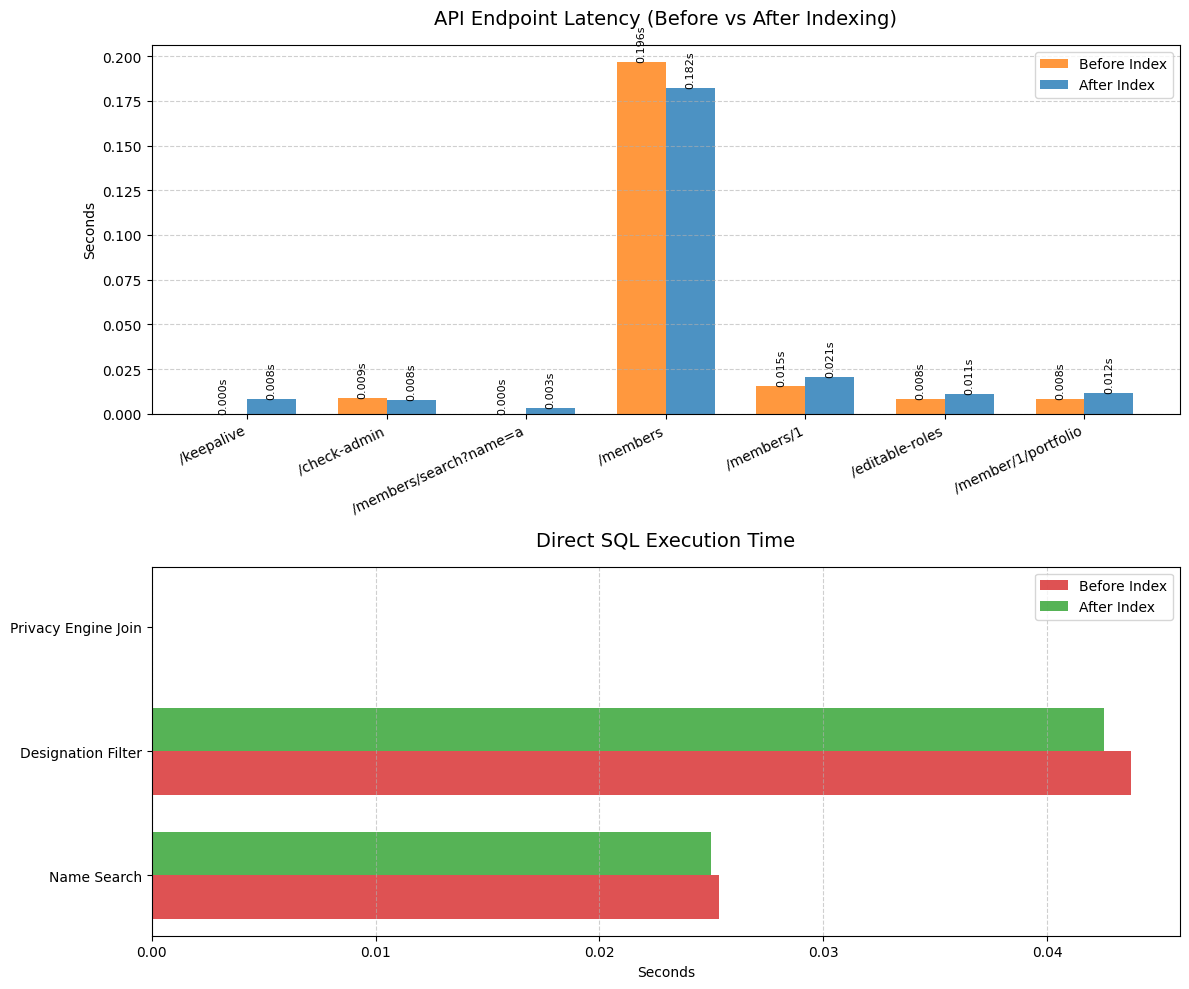

In [6]:
import json
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

# Adjusting paths to find the benchmarks folder in Module B
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'benchmarks'))
GRAPH_DIR = os.path.join(BASE_DIR, 'graphs')
os.makedirs(GRAPH_DIR, exist_ok=True)

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

# Using your specific glob patterns
api_before_files = glob.glob(os.path.join(BASE_DIR, '*api_times_before*.json'))
api_after_files  = glob.glob(os.path.join(BASE_DIR, '*api_times_after*.json'))
prof_before_files = glob.glob(os.path.join(BASE_DIR, '*benchmark_profile_before*.json'))
prof_after_files  = glob.glob(os.path.join(BASE_DIR, '*benchmark_profile_after*.json'))

if not (api_before_files and api_after_files and prof_before_files and prof_after_files):
    print(f"Looked in: {BASE_DIR}")
    raise FileNotFoundError("Required benchmark JSON files not found. Run benchmark_and_index.py first.")

def plot_combined():
    api_b = load_json(api_before_files[0])
    api_a = load_json(api_after_files[0])
    prof_b = load_json(prof_before_files[0])
    prof_a = load_json(prof_after_files[0])

    # Mapping API results (using 'endpoint' and 'time' from our script)
    api_keys = [p['endpoint'] for p in api_b]
    api_before_vals = [float(p['time']) for p in api_b]
    # Match order of endpoints
    api_after_map = {p['endpoint']: float(p['time']) for p in api_a}
    api_after_vals = [api_after_map.get(k, 0) for k in api_keys]

    # Mapping SQL Profile results (using 'desc' and 'time' from our script)
    prof_keys = [p['desc'] for p in prof_b]
    prof_before_vals = [float(p['time']) for p in prof_b]
    prof_after_map = {p['desc']: float(p['time']) for p in prof_a}
    prof_after_vals = [prof_after_map.get(k, 0) for k in prof_keys]

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    width = 0.35
    indices = np.arange(len(api_keys))

    # --- Plot 1: API Comparison ---
    axes[0].bar(indices - width/2, api_before_vals, width, label='Before Index', color='#ff7f0e', alpha=0.8)
    axes[0].bar(indices + width/2, api_after_vals, width, label='After Index', color='#1f77b4', alpha=0.8)
    
    # Annotate values
    for i, v in enumerate(api_before_vals):
        axes[0].text(i - width/2, v, f"{v:.3f}s", ha='center', va='bottom', fontsize=8, rotation=90)
    for i, v in enumerate(api_after_vals):
        axes[0].text(i + width/2, v, f"{v:.3f}s", ha='center', va='bottom', fontsize=8, rotation=90)

    axes[0].set_title('API Endpoint Latency (Before vs After Indexing)', fontsize=14, pad=15)
    axes[0].set_xticks(indices)
    axes[0].set_xticklabels(api_keys, rotation=25, ha='right')
    axes[0].set_ylabel('Seconds')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)
    axes[0].legend()

    # --- Plot 2: SQL Profile Comparison ---
    indices_sql = np.arange(len(prof_keys))
    axes[1].barh(indices_sql - width/2, prof_before_vals, width, label='Before Index', color='#d62728', alpha=0.8)
    axes[1].barh(indices_sql + width/2, prof_after_vals, width, label='After Index', color='#2ca02c', alpha=0.8)

    axes[1].set_title('Direct SQL Execution Time', fontsize=14, pad=15)
    axes[1].set_yticks(indices_sql)
    axes[1].set_yticklabels(prof_keys)
    axes[1].set_xlabel('Seconds')
    axes[1].grid(axis='x', linestyle='--', alpha=0.6)
    axes[1].legend()

    plt.tight_layout()
    output_path = os.path.join(GRAPH_DIR, 'benchmarking_results.png')
    plt.savefig(output_path, dpi=300)
    print(f"Graph saved to: {output_path}")
    plt.show()

if __name__ == "__main__":
    plot_combined()

## EXPLAIN Plan Samples
Below are the EXPLAIN outputs captured in `callhub_benchmark_profile.json`. Each entry has an `explain` array containing explain rows. You can inspect these programmatically or copy them into the report PDF.

In [5]:
import glob, os, json

# 1. Look one directory up ('..') to find the 'benchmarks' folder
# 2. Match your actual filenames ('benchmark_profile_*.json')
search_pattern = os.path.join('..', 'benchmarks', 'benchmark_profile_*.json')
profile_files = sorted(glob.glob(search_pattern))

if not profile_files:
    print(f"Still no files found. Please check: {os.path.abspath(search_pattern)}")

for pf in profile_files:
    with open(pf, 'r') as f:
        data = json.load(f)
        
    if not data:
        continue
        
    print('===', os.path.basename(pf))
    for item in data:
        print('---', item.get('desc'))
        explain = item.get('explain', [])
        if isinstance(explain, list):
            for row in explain[:5]:
                print(row)
        else:
            print(explain)
        print('\n')

=== benchmark_profile_after.json
--- Name Search
{'id': 1, 'select_type': 'SIMPLE', 'table': 'Members', 'partitions': None, 'type': 'range', 'possible_keys': 'idx_members_name', 'key': 'idx_members_name', 'key_len': '402', 'ref': None, 'rows': 4056, 'filtered': 100.0, 'Extra': 'Using index condition'}


--- Designation Filter
{'id': 1, 'select_type': 'SIMPLE', 'table': 'Members', 'partitions': None, 'type': 'ref', 'possible_keys': 'idx_members_lookup', 'key': 'idx_members_lookup', 'key_len': '404', 'ref': 'const,const', 'rows': 16562, 'filtered': 100.0, 'Extra': None}


--- Privacy Engine Join
{'id': 1, 'select_type': 'SIMPLE', 'table': 'mra', 'partitions': None, 'type': 'ref', 'possible_keys': 'role_id,idx_mra_comp', 'key': 'idx_mra_comp', 'key_len': '4', 'ref': 'const', 'rows': 1, 'filtered': 100.0, 'Extra': 'Using index; Using temporary'}
{'id': 1, 'select_type': 'SIMPLE', 'table': 'rp', 'partitions': None, 'type': 'ref', 'possible_keys': 'category_id,idx_rp_comp', 'key': 'idx_rp_co